### Reason backwards

$$𝑝(𝐸|𝐶) \cdot 𝑝(𝐶) = 𝑝(𝐶|𝐸) \cdot 𝑝(𝐸)$$


##### 1. Take the COVID-19 example from the lecture as a basis and implement a Python class that enables to reason from a single effect to the cause. Provide appropriate methods to input the required numbers.

In [8]:
class ReasonBackwards:
    def __init__(self, probability_cause, probability_effect, probability_cause_given_effect):
        self.probability_cause = probability_cause
        self.probability_effect = probability_effect
        self.probability_cause_given_effect = probability_cause_given_effect

    def calculate_probability_effect_given_cause(self):
        if self.probability_cause == 0:
            raise ValueError("Probability of cause cannot be zero.")
        
        # print(f'P(C) = {self.probability_cause}\nP(E) = {self.probability_effect}\nP(C|E) = {self.probability_cause_given_effect}')

        return (self.probability_cause_given_effect * self.probability_effect) / self.probability_cause

- `probability_cause` - P(cause) - Prawdopodobieństwo, że przyczyna wystąpi                           
- `probability_effect` - P(effect) - Prawdopodobieństwo, że skutek wystąpi                              
- `probability_cause_given_effect` - P(cause|effect) - Prawdopodobieństwo, że przyczyna wystąpi, jeśli obserwujemy skutek 

**Prawdopodobieństwo, że skutek wystąpi, jeśli przyczyna wystąpi**
- P(effect|cause) - (wyliczane przez metodę `calculate_probability_effect_given_cause`)


Case #1

In [9]:
probability_covid = 237118/38268000
probability_loss_of_smell = 0.01
probability_loss_of_smell_given_covid = 0.9

reasoner = ReasonBackwards(probability_loss_of_smell, probability_covid, probability_loss_of_smell_given_covid)
probability_covid_given_loss_of_smell = reasoner.calculate_probability_effect_given_cause()

print(f"P(C|L) = {probability_covid_given_loss_of_smell:.3f}")

P(C|L) = 0.558


Case #2

Loss of smell was a very common complaint.

In [10]:
probability_loss_of_smell = 0.1

reasoner = ReasonBackwards(probability_loss_of_smell, probability_covid, probability_loss_of_smell_given_covid)
probability_covid_given_loss_of_smell = reasoner.calculate_probability_effect_given_cause()
print(f"P(C|L) = {probability_covid_given_loss_of_smell:.3f}")

P(C|L) = 0.056


Case #3 

Loss of smell was present only rarely during COVID-19 infection.

In [11]:
probability_loss_of_smell = 0.01
probability_loss_of_smell_given_covid = 0.1

reasoner = ReasonBackwards(probability_loss_of_smell, probability_covid, probability_loss_of_smell_given_covid)
probability_covid_given_loss_of_smell = reasoner.calculate_probability_effect_given_cause()
print(f"P(C|L) = {probability_covid_given_loss_of_smell:.3f}")

P(C|L) = 0.062


Case #4

Not having symptoms.

In [12]:
probability_loss_of_smell = 0.01
probability_loss_of_smell_given_covid = 0.9

probability_not_loss_of_smell = 1 - probability_loss_of_smell
probability_not_loss_of_smell_given_covid = 1 - probability_loss_of_smell_given_covid

reasoner = ReasonBackwards(probability_not_loss_of_smell, probability_covid, probability_not_loss_of_smell_given_covid)
probability_covid_given_not_loss_of_smell = reasoner.calculate_probability_effect_given_cause()
print(f"P(C|~L) = {probability_covid_given_not_loss_of_smell:.5f}")

P(C|~L) = 0.00063


##### 2. Play with the class, plot output for different combinations of inputs.

In [13]:
examples = [
    (0.5, 0.05, 0.8),   
    (0.01, 0.9, 0.05),   
    (0.8, 0.2, 0.3),     
    (0.05, 0.05, 0.95),  
    (0.3, 0.7, 0.1)      
]

for i, (prob_cause, prob_effect, prob_cause_given_effect) in enumerate(examples, 1):
    reasoner = ReasonBackwards(prob_cause, prob_effect, prob_cause_given_effect)
    result = reasoner.calculate_probability_effect_given_cause()
    print(f"Example #{i}: P(C)={prob_cause}, P(E)={prob_effect}, P(C|E)={prob_cause_given_effect} => P(E|C)={result:.4f}\n")

Example #1: P(C)=0.5, P(E)=0.05, P(C|E)=0.8 => P(E|C)=0.0800

Example #2: P(C)=0.01, P(E)=0.9, P(C|E)=0.05 => P(E|C)=4.5000

Example #3: P(C)=0.8, P(E)=0.2, P(C|E)=0.3 => P(E|C)=0.0750

Example #4: P(C)=0.05, P(E)=0.05, P(C|E)=0.95 => P(E|C)=0.9500

Example #5: P(C)=0.3, P(E)=0.7, P(C|E)=0.1 => P(E|C)=0.2333



**Wykres**

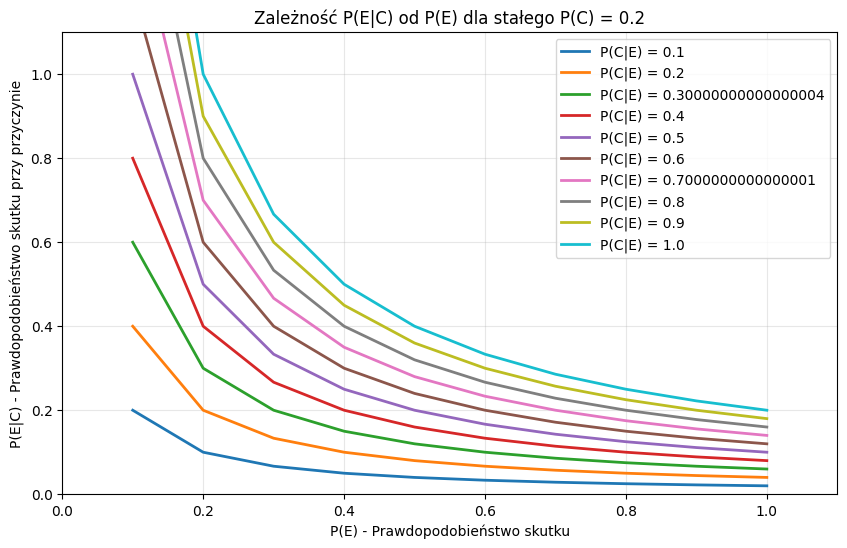

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

prob_cause = 0.2
prob_effect_table = np.linspace(0.1, 1, 10)  # zakres wartości P(E)
prob_cause_given_effect_values = np.linspace(0.1, 1, 10) 

plt.figure(figsize=(10, 6))

for P_C_given_E in prob_cause_given_effect_values:
    P_E_given_C_values = []
    
    for P_E in prob_effect_table:
        reasoner = ReasonBackwards(P_E, prob_cause, P_C_given_E)
        try:
            P_E_given_C = reasoner.calculate_probability_effect_given_cause()
            P_E_given_C_values.append(P_E_given_C)
        except:
            P_E_given_C_values.append(np.nan)

    plt.plot(prob_effect_table, P_E_given_C_values, label=f'P(C|E) = {P_C_given_E}', linewidth=2)

plt.xlabel('P(E) - Prawdopodobieństwo skutku')
plt.ylabel('P(E|C) - Prawdopodobieństwo skutku przy przyczynie')
plt.title(f'Zależność P(E|C) od P(E) dla stałego P(C) = {prob_cause}')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xlim(0, 1.1)
plt.ylim(0, 1.1)
plt.show()

##### 3. Test the class for p(C)=0.2, P(L)=0.001, P(L|C)=0.01. What happened? Why? How to fix it?

In [15]:
probability_covid = 0.2
probability_loss_of_smell = 0.001
probability_loss_of_smell_given_covid = 0.01

reasoner = ReasonBackwards(probability_loss_of_smell, probability_covid, probability_loss_of_smell_given_covid)
probability_covid_given_loss_of_smell = reasoner.calculate_probability_effect_given_cause()
print(f"P(C|L) = {probability_covid_given_loss_of_smell:.3f}")

P(C|L) = 2.000


**Wzór na prawdopodobieństwo całkowite**

Dla pełnego systemu zdarzeń B₁, B₂, ..., Bₙ (gdzie zdarzenia są rozłączne i wyczerpujące):

$$P(A) = \sum_{i=1}^{n} P(A|B_i)P(B_i) = 1$$

**W przypadku dwóch zdarzeń wykluczających się (np. C i ¬C):**

$$P(A) = P(A|C) \cdot P(C) + P(A|\neg C) \cdot P(\neg C)$$

gdzie $P(C) + P(\neg C) = 1$

**Aplikacja do naszego problemu:**

P(L) = P(L|C) × P(C) + P(L|¬C) × P(¬C)
P(L) = P(L|C) × P(C) + P(L|¬C) × (1 - P(C))

**Sprawdzenie dla Case #3:**

0.001 ≟ 0.01 × 0.2 + P(L|¬C) × 0.8
0.001 ≟ 0.002 + P(L|¬C) × 0.8
P(L|¬C) = (0.001 - 0.002) / 0.8 = -0.00125

Ujemne prawdopodobieństwo jest niemożliwe - stąd błąd w obliczeniach Bayesa.